In [5]:
%pip install torchvision --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


Using device: mps
Training samples:   54000
Validation samples: 6000
Test samples:       10000

Training: Base LeNet-5 (No Regularization)
Epoch [ 1/10] | Loss: 0.6555 | Train Acc: 82.91% | Val Acc: 82.53% | Test Acc: 81.92%
Epoch [ 2/10] | Loss: 0.4217 | Train Acc: 86.32% | Val Acc: 85.63% | Test Acc: 85.01%
Epoch [ 3/10] | Loss: 0.3609 | Train Acc: 87.36% | Val Acc: 86.45% | Test Acc: 85.96%
Epoch [ 4/10] | Loss: 0.3242 | Train Acc: 88.72% | Val Acc: 87.47% | Test Acc: 87.12%
Epoch [ 5/10] | Loss: 0.2996 | Train Acc: 89.30% | Val Acc: 88.18% | Test Acc: 87.26%
Epoch [ 6/10] | Loss: 0.2809 | Train Acc: 90.32% | Val Acc: 88.92% | Test Acc: 88.63%
Epoch [ 7/10] | Loss: 0.2626 | Train Acc: 90.78% | Val Acc: 89.23% | Test Acc: 88.85%
Epoch [ 8/10] | Loss: 0.2499 | Train Acc: 91.49% | Val Acc: 89.63% | Test Acc: 89.16%
Epoch [ 9/10] | Loss: 0.2348 | Train Acc: 92.32% | Val Acc: 90.02% | Test Acc: 89.70%
Epoch [10/10] | Loss: 0.2230 | Train Acc: 92.06% | Val Acc: 89.75% | Test Acc: 89.39%



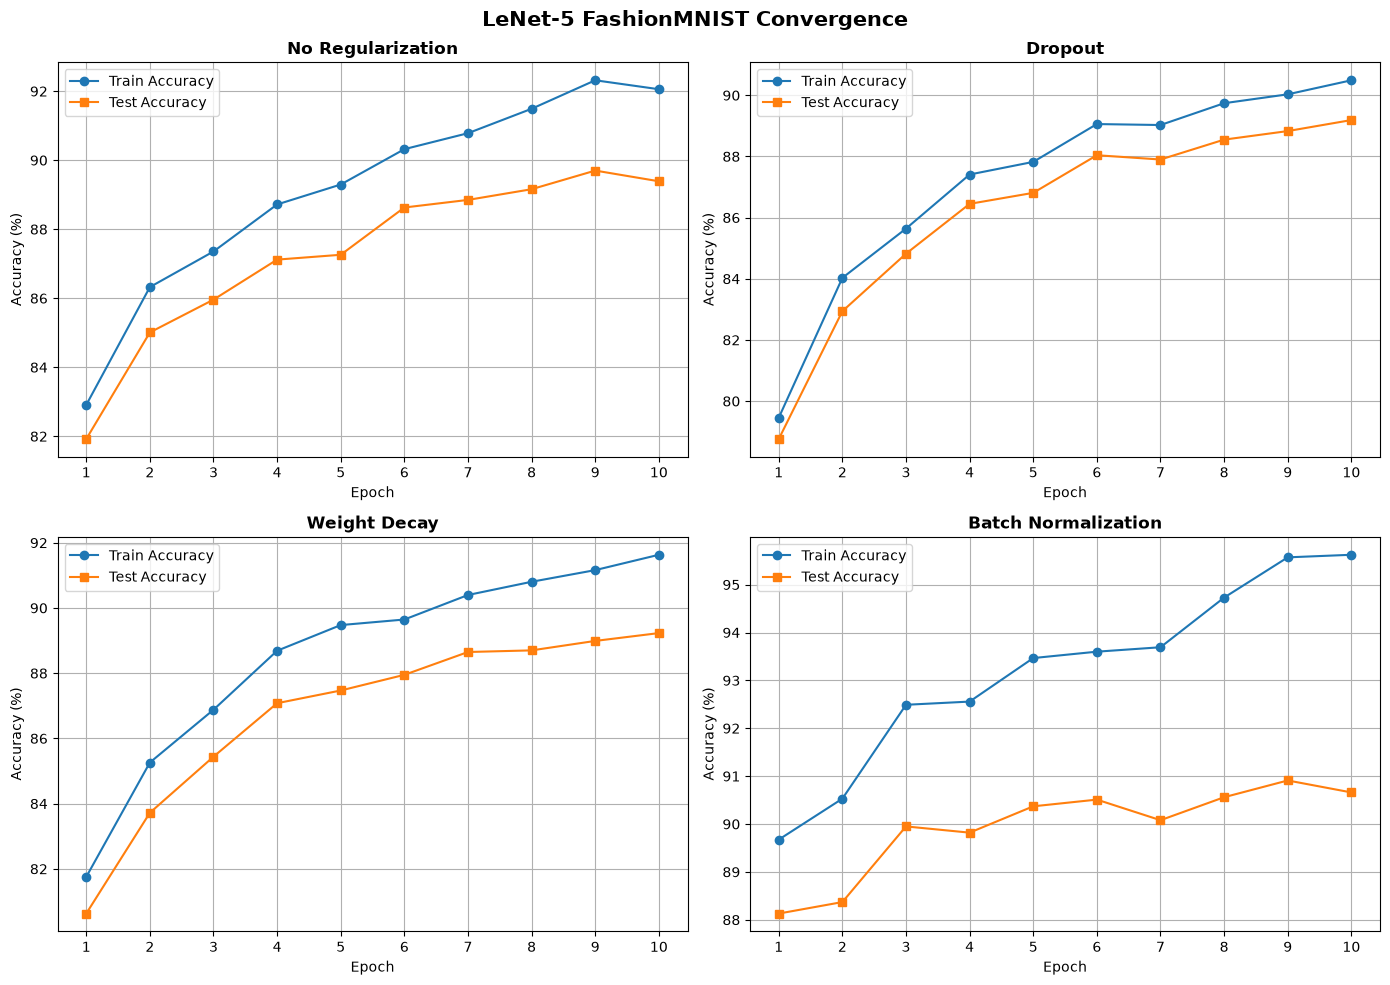



Technique             Best Epoch    Val Acc (%)    Train Acc (%)    Test Acc (%)   
No Regularization     9             90.02          92.32            89.70          
Dropout               10            89.02          90.49            89.19          
Weight Decay          9             89.50          91.16            88.99          
Batch Normalization   9             91.13          95.57            90.91          

88% Test Accuracy Requirement
---------------------------------------------
No Regularization     : 89.70%  [PASS]
Dropout               : 89.19%  [PASS]
Weight Decay          : 88.99%  [PASS]
Batch Normalization   : 90.91%  [PASS]


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt



SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)



BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10

DROPOUT_RATE = 0.5
WEIGHT_DECAY = 1e-4

TRAIN_SIZE = 54000
VAL_SIZE = 6000



transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])


full_train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


split_generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    full_train_set,
    [TRAIN_SIZE, VAL_SIZE],
    generator=split_generator
)


train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(f"Training samples:   {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples:       {len(test_set)}")




class LeNet5Base(nn.Module):

    def __init__(self):
        super().__init__()

        # Input: 1 x 28 x 28

        # Output: 6 x 28 x 28
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5,
            padding=2
        )

        # Output after pooling: 6 x 14 x 14
        self.pool1 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # Output: 16 x 10 x 10
        self.conv2 = nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=5
        )

        # Output after pooling: 16 x 5 x 5
        self.pool2 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x



class LeNet5Dropout(nn.Module):

    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            6,
            kernel_size=5,
            padding=2
        )

        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            6,
            16,
            kernel_size=5
        )

        self.pool2 = nn.AvgPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(120, 84)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x


class LeNet5BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            6,
            kernel_size=5,
            padding=2
        )

        self.bn1 = nn.BatchNorm2d(6)

        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            6,
            16,
            kernel_size=5
        )

        self.bn2 = nn.BatchNorm2d(16)

        self.pool2 = nn.AvgPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.bn_fc1 = nn.BatchNorm1d(120)

        self.fc2 = nn.Linear(120, 84)
        self.bn_fc2 = nn.BatchNorm1d(84)

        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        # Conv -> BatchNorm -> ReLU -> Pool
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        # FC -> BatchNorm -> ReLU
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


def compute_accuracy(model, loader):


    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predicted = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100.0 * correct / total

    return accuracy



def run_experiment(
    model,
    name,
    save_filename,
    weight_decay=0.0,
    epochs=10
):

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=weight_decay
    )

    train_acc_history = []
    val_acc_history = []
    test_acc_history = []


    best_val_acc = -1.0
    best_epoch = 0


    for epoch in range(epochs):



        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )


        average_loss = (
            running_loss /
            len(train_loader.dataset)
        )



        train_acc = compute_accuracy(
            model,
            train_loader
        )

        val_acc = compute_accuracy(
            model,
            val_loader
        )


        test_acc = compute_accuracy(
            model,
            test_loader
        )


        train_acc_history.append(
            train_acc
        )

        val_acc_history.append(
            val_acc
        )

        test_acc_history.append(
            test_acc
        )


        print(
            f"Epoch [{epoch + 1:2d}/{epochs}] "
            f"| Loss: {average_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Val Acc: {val_acc:.2f}% "
            f"| Test Acc: {test_acc:.2f}%"
        )


        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_epoch = epoch + 1

            torch.save(
                model.state_dict(),
                save_filename
            )



    model.load_state_dict(
        torch.load(
            save_filename,
            map_location=device
        )
    )


    # Evaluate the selected best-validation model
    final_train_acc = compute_accuracy(
        model,
        train_loader
    )

    final_val_acc = compute_accuracy(
        model,
        val_loader
    )

    final_test_acc = compute_accuracy(
        model,
        test_loader
    )


    print("\nBest Model Selection")
    print("-" * 70)

    print(
        f"Best epoch:               {best_epoch}"
    )

    print(
        f"Best validation accuracy: {best_val_acc:.2f}%"
    )

    print(
        f"Selected Train Accuracy:  {final_train_acc:.2f}%"
    )

    print(
        f"Selected Test Accuracy:   {final_test_acc:.2f}%"
    )

    print(
        f"Model saved to:           {save_filename}"
    )


    return {

        "train_history":
            train_acc_history,

        "val_history":
            val_acc_history,

        "test_history":
            test_acc_history,

        "best_epoch":
            best_epoch,

        "best_val":
            best_val_acc,

        "final_train":
            final_train_acc,

        "final_val":
            final_val_acc,

        "final_test":
            final_test_acc
    }



results = {}


results["Base"] = run_experiment(

    model=LeNet5Base(),

    name="Base LeNet-5 (No Regularization)",

    save_filename="lenet5_base.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)


results["Dropout"] = run_experiment(

    model=LeNet5Dropout(
        dropout_rate=DROPOUT_RATE
    ),

    name="LeNet-5 + Dropout",

    save_filename="lenet5_dropout.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)


results["Weight Decay"] = run_experiment(

    model=LeNet5Base(),

    name="LeNet-5 + Weight Decay (L2)",

    save_filename="lenet5_weight_decay.pth",

    weight_decay=WEIGHT_DECAY,

    epochs=EPOCHS
)



results["BatchNorm"] = run_experiment(

    model=LeNet5BatchNorm(),

    name="LeNet-5 + Batch Normalization",

    save_filename="lenet5_batchnorm.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


epochs_range = range(
    1,
    EPOCHS + 1
)


keys = [
    "Base",
    "Dropout",
    "Weight Decay",
    "BatchNorm"
]


titles = {
    "Base":
        "No Regularization",

    "Dropout":
        "Dropout",

    "Weight Decay":
        "Weight Decay",

    "BatchNorm":
        "Batch Normalization"
}


for idx, key in enumerate(keys):

    row = idx // 2
    col = idx % 2

    ax = axes[row, col]


    train_acc = (
        results[key]["train_history"]
    )

    test_acc = (
        results[key]["test_history"]
    )


    ax.plot(
        epochs_range,
        train_acc,
        marker="o",
        label="Train Accuracy"
    )

    ax.plot(
        epochs_range,
        test_acc,
        marker="s",
        label="Test Accuracy"
    )


    ax.set_title(
        titles[key],
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Accuracy (%)"
    )

    ax.set_xticks(
        list(epochs_range)
    )

    ax.legend()

    ax.grid(True)


plt.suptitle(
    "LeNet-5 FashionMNIST Convergence",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()


plt.savefig(
    "lenet5_convergence.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("\n")
print("=" * 90)

print(
    f"{'Technique':<22}"
    f"{'Best Epoch':<14}"
    f"{'Val Acc (%)':<15}"
    f"{'Train Acc (%)':<17}"
    f"{'Test Acc (%)':<15}"
)

print("=" * 90)


for key in keys:

    best_epoch = (
        results[key]["best_epoch"]
    )

    final_val = (
        results[key]["final_val"]
    )

    final_train = (
        results[key]["final_train"]
    )

    final_test = (
        results[key]["final_test"]
    )


    print(
        f"{titles[key]:<22}"
        f"{best_epoch:<14}"
        f"{final_val:<15.2f}"
        f"{final_train:<17.2f}"
        f"{final_test:<15.2f}"
    )


print("=" * 90)


print("\n88% Test Accuracy Requirement")
print("-" * 45)


for key in keys:

    test_acc = (
        results[key]["final_test"]
    )

    if test_acc >= 88.0:
        status = "PASS"
    else:
        status = "BELOW 88%"


    print(
        f"{titles[key]:<22}: "
        f"{test_acc:.2f}%  [{status}]"
    )

### Conclusion

All four LeNet-5 configurations achieved more than 88% test accuracy. The model with Batch Normalization achieved the highest test accuracy at 90.91% and also had the highest validation accuracy, showing the strongest overall performance in this experiment. Dropout achieved a test accuracy of 89.19% and had the smallest gap between training and test accuracy, which suggests stronger regularization and less overfitting. Weight Decay achieved 88.99% test accuracy, which was slightly lower than the baseline model's 89.70%. Overall, Batch Normalization improved performance the most, while Dropout was more effective at reducing the gap between training and test accuracy.